In [1]:
# ═══════════════════════════════════════════════════════════
# GLOBAL CONFIGURATION
# ═══════════════════════════════════════════════════════════
import gc
import logging
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)

PROJECT_ROOT = Path(".")
MODELS_DIR   = PROJECT_ROOT / "models"
DATA_DIR     = PROJECT_ROOT / "data" / "model_inputs"
ARCHIVE_DIR  = PROJECT_ROOT / "archive"

TRAIN_END  = '2017-12-31 23:00:00'
VAL_START  = '2018-01-01 00:00:00'
VAL_END    = '2018-06-30 23:00:00'

# ── LOAD MASTER DATAFRAME & TSO FORECAST ──
try:
    # 1. Load the primary operational matrix
    master_df = pd.read_parquet(DATA_DIR / "df_improved_trees.parquet", engine="fastparquet")
    
    # 2. Extract the official TSO day-ahead forecast from the raw archive
    # We only read the necessary columns to save memory
    raw_tso = pd.read_csv(ARCHIVE_DIR / "energy_dataset.csv", usecols=['time', 'total load forecast'])
    
    # Standardize the timestamp to match master_df's index (Europe/Madrid, tz-naive)
    raw_tso['time'] = pd.to_datetime(raw_tso['time'], utc=True).dt.tz_convert('Europe/Madrid').dt.tz_localize(None)
    raw_tso.set_index('time', inplace=True)
    
    # 3. Safely align and merge the TSO forecast into our master matrix
    master_df = master_df.join(raw_tso['total load forecast'], how='left')
    
except FileNotFoundError as e:
    print(f"⚠️ Warning: {e}. Please ensure Notebook 01 has been executed and the archive folder exists.")

# Accumulator for the final leaderboard
ALL_RESULTS = []

print("✅ Global configuration, master_df, and TSO forecasts loaded successfully.")

✅ Global configuration, master_df, and TSO forecasts loaded successfully.


In [2]:
# ═══════════════════════════════════════════════════════════
# DATA LOADING & MASTER DF CONSTRUCTION
# ═══════════════════════════════════════════════════════════

import os

# Build the master dataset via our processing pipeline ──
import sys

# The src directory has a trailing space in its name
sys.path.insert(0, os.path.join(os.getcwd(), "src "))

from src.data.data_preprocessing import process_energy_base, process_weather_pipeline

energy_clean  = process_energy_base("./archive/energy_dataset.csv")
weather_clean = process_weather_pipeline("./archive/weather_features.csv")

master_df = energy_clean.join(weather_clean, how='inner')
master_df = master_df.dropna(subset=['total load actual'])

print(f"Master dataset: {master_df.shape[0]:,} rows × {master_df.shape[1]} cols")
print(f"Period: {master_df.index.min()} → {master_df.index.max()}")
master_df.head(3)
# ── Chronological Split ──
TRAIN_END = '2017-12-31 23:00:00'
VAL_END   = '2018-06-30 23:00:00'

train_df = master_df.loc[:TRAIN_END].copy()
val_df   = master_df.loc[TRAIN_END:VAL_END].iloc[1:].copy()   # exclude last train hour
test_df  = master_df.loc[VAL_END:].iloc[1:].copy()

print(f"Train:      {train_df.shape[0]:>7,} rows  [{train_df.index.min()} → {train_df.index.max()}]")
print(f"Validation: {val_df.shape[0]:>7,} rows  [{val_df.index.min()} → {val_df.index.max()}]")
print(f"Test:       {test_df.shape[0]:>7,} rows  [{test_df.index.min()} → {test_df.index.max()}]")
# 1. Purge the Daylight Saving Time duplicate indices
master_df = master_df[~master_df.index.duplicated(keep='first')]
val_df = val_df[~val_df.index.duplicated(keep='first')]

# 2. Recalculate the shift safely
naive_pred = master_df['total load actual'].shift(168)

# 3. Align strictly to the Validation index (will now work perfectly)
val_naive = pd.DataFrame({
    'actual': val_df['total load actual'],
    'naive_168': naive_pred.reindex(val_df.index)
}).dropna()

# 4. Metrics
mae_naive  = mean_absolute_error(val_naive['actual'], val_naive['naive_168'])
mape_naive = np.mean(np.abs(
    (val_naive['actual'] - val_naive['naive_168']) / val_naive['actual']
)) * 100

print("═══ Floor: Seasonal Naïve (168 h shift) — Validation Set ═══")
print(f"  MAE  = {mae_naive:,.1f} MW")
print(f"  MAPE = {mape_naive:.2f}%")

Master dataset: 35,060 rows × 57 cols
Period: 2015-01-01 00:00:00 → 2018-12-31 23:00:00
Train:       26,301 rows  [2015-01-01 00:00:00 → 2017-12-31 23:00:00]
Validation:   4,343 rows  [2018-01-01 00:00:00 → 2018-06-30 23:00:00]
Test:         4,416 rows  [2018-07-01 00:00:00 → 2018-12-31 23:00:00]
═══ Floor: Seasonal Naïve (168 h shift) — Validation Set ═══
  MAE  = 2,685.4 MW
  MAPE = 9.20%


In [3]:
from src.evaluation.evaluator import ModelEvaluator

ALL_RESULTS = []

evaluator = ModelEvaluator(
    train_end='2017-12-31 23:00:00',
    eval_start='2018-01-01 00:00:00',
    eval_end='2018-06-30 23:00:00',
    results_list=ALL_RESULTS
)

Importing plotly failed. Interactive plots will not work.


## 6. Methodology & Architecture Selection

This section analyzes the unbiased performance of the best configuration on the held out test set

In [5]:
# ══════════════════════════════════════════════════════════════════════════
# STAGE 6A · THE VAULT: UNBIASED TEST SET EVALUATION (NUMERICAL)
# ══════════════════════════════════════════════════════════════════════════
print("═" * 70)
print("  STAGE 6A · THE VAULT: MLOPS TEST SET EVALUATION")
print("═" * 70)

S6 = "Stage 6: The Vault (Test Set)"
TEST_CACHE_FILE = MODELS_DIR / "mlops_test_predictions_probabilistic.pkl"
TEST_START = '2018-07-01 00:00:00'

if TEST_CACHE_FILE.exists():
    import joblib
    print("✅ Found cached Probabilistic Test Set MLOps predictions!")
    
    # Load the dictionary containing all quantiles
    prob_results = joblib.load(TEST_CACHE_FILE)
    test_actuals = np.array(prob_results['actuals'])
    test_preds_median = np.array(prob_results['q50']) # Extracting the pure Median!
    
    # 1. Calculate the Ultimate Champion Metrics
    mae_test, mape_test = evaluator.compute_metrics(test_actuals, test_preds_median)
    evaluator.record_result(S6, "LightGBM Intraday MLOps (Median) [Test Set]", mae_test, mape_test, horizon="Intraday (h=1)")
    
    # 2. Extract the TSO Official Forecast directly from the in-memory master_df
    try:
        test_mask = master_df.index >= TEST_START
        df_test_tso = master_df.loc[test_mask, ['total load actual', 'total load forecast']].dropna()
        
        y_test_true = df_test_tso['total load actual'].values
        y_test_tso = df_test_tso['total load forecast'].values
        
        mae_tso, mape_tso = evaluator.compute_metrics(y_test_true, y_test_tso)
        evaluator.record_result(S6, "TSO Official Forecast [Test Set Ceiling]", mae_tso, mape_tso, horizon="Day-Ahead (h=24)")
        
        print("\n" + "─" * 70)
        print("🏆 FINAL TEST SET SHOWDOWN (PROBABILISTIC MEDIAN)")
        print("─" * 70)
        print(f"🏛️  TSO Official Forecast :  MAE = {mae_tso:,.1f} MW   | MAPE = {mape_tso:.2f}%")
        print(f"🚀  LightGBM MLOps (q50)  :  MAE = {mae_test:,.1f} MW   | MAPE = {mape_test:.2f}%")
        print("─" * 70)
        
    except Exception as e:
        print(f"\n⚠️ Could not evaluate TSO Test Forecast: {e}")
        print("\n" + "─" * 70)
        print(f"📊 Final Test MAE  : {mae_test:,.1f} MW")
        print(f"📊 Final Test MAPE : {mape_test:.2f} %")
        print("─" * 70)


else:
    print("❌ Probabilistic Test Cache not found!")
    print("   Please run: uv run python src/evaluate_test_mlops.py")

══════════════════════════════════════════════════════════════════════
  STAGE 6A · THE VAULT: MLOPS TEST SET EVALUATION
══════════════════════════════════════════════════════════════════════
✅ Found cached Probabilistic Test Set MLOps predictions!
  ✅ LightGBM Intraday MLOps (Median) [Test Set]  MAE =    251.9 MW   MAPE = 0.88%
  ✅ TSO Official Forecast [Test Set Ceiling]  MAE =    258.6 MW   MAPE = 0.89%

──────────────────────────────────────────────────────────────────────
🏆 FINAL TEST SET SHOWDOWN (PROBABILISTIC MEDIAN)
──────────────────────────────────────────────────────────────────────
🏛️  TSO Official Forecast :  MAE = 258.6 MW   | MAPE = 0.89%
🚀  LightGBM MLOps (q50)  :  MAE = 251.9 MW   | MAPE = 0.88%
──────────────────────────────────────────────────────────────────────


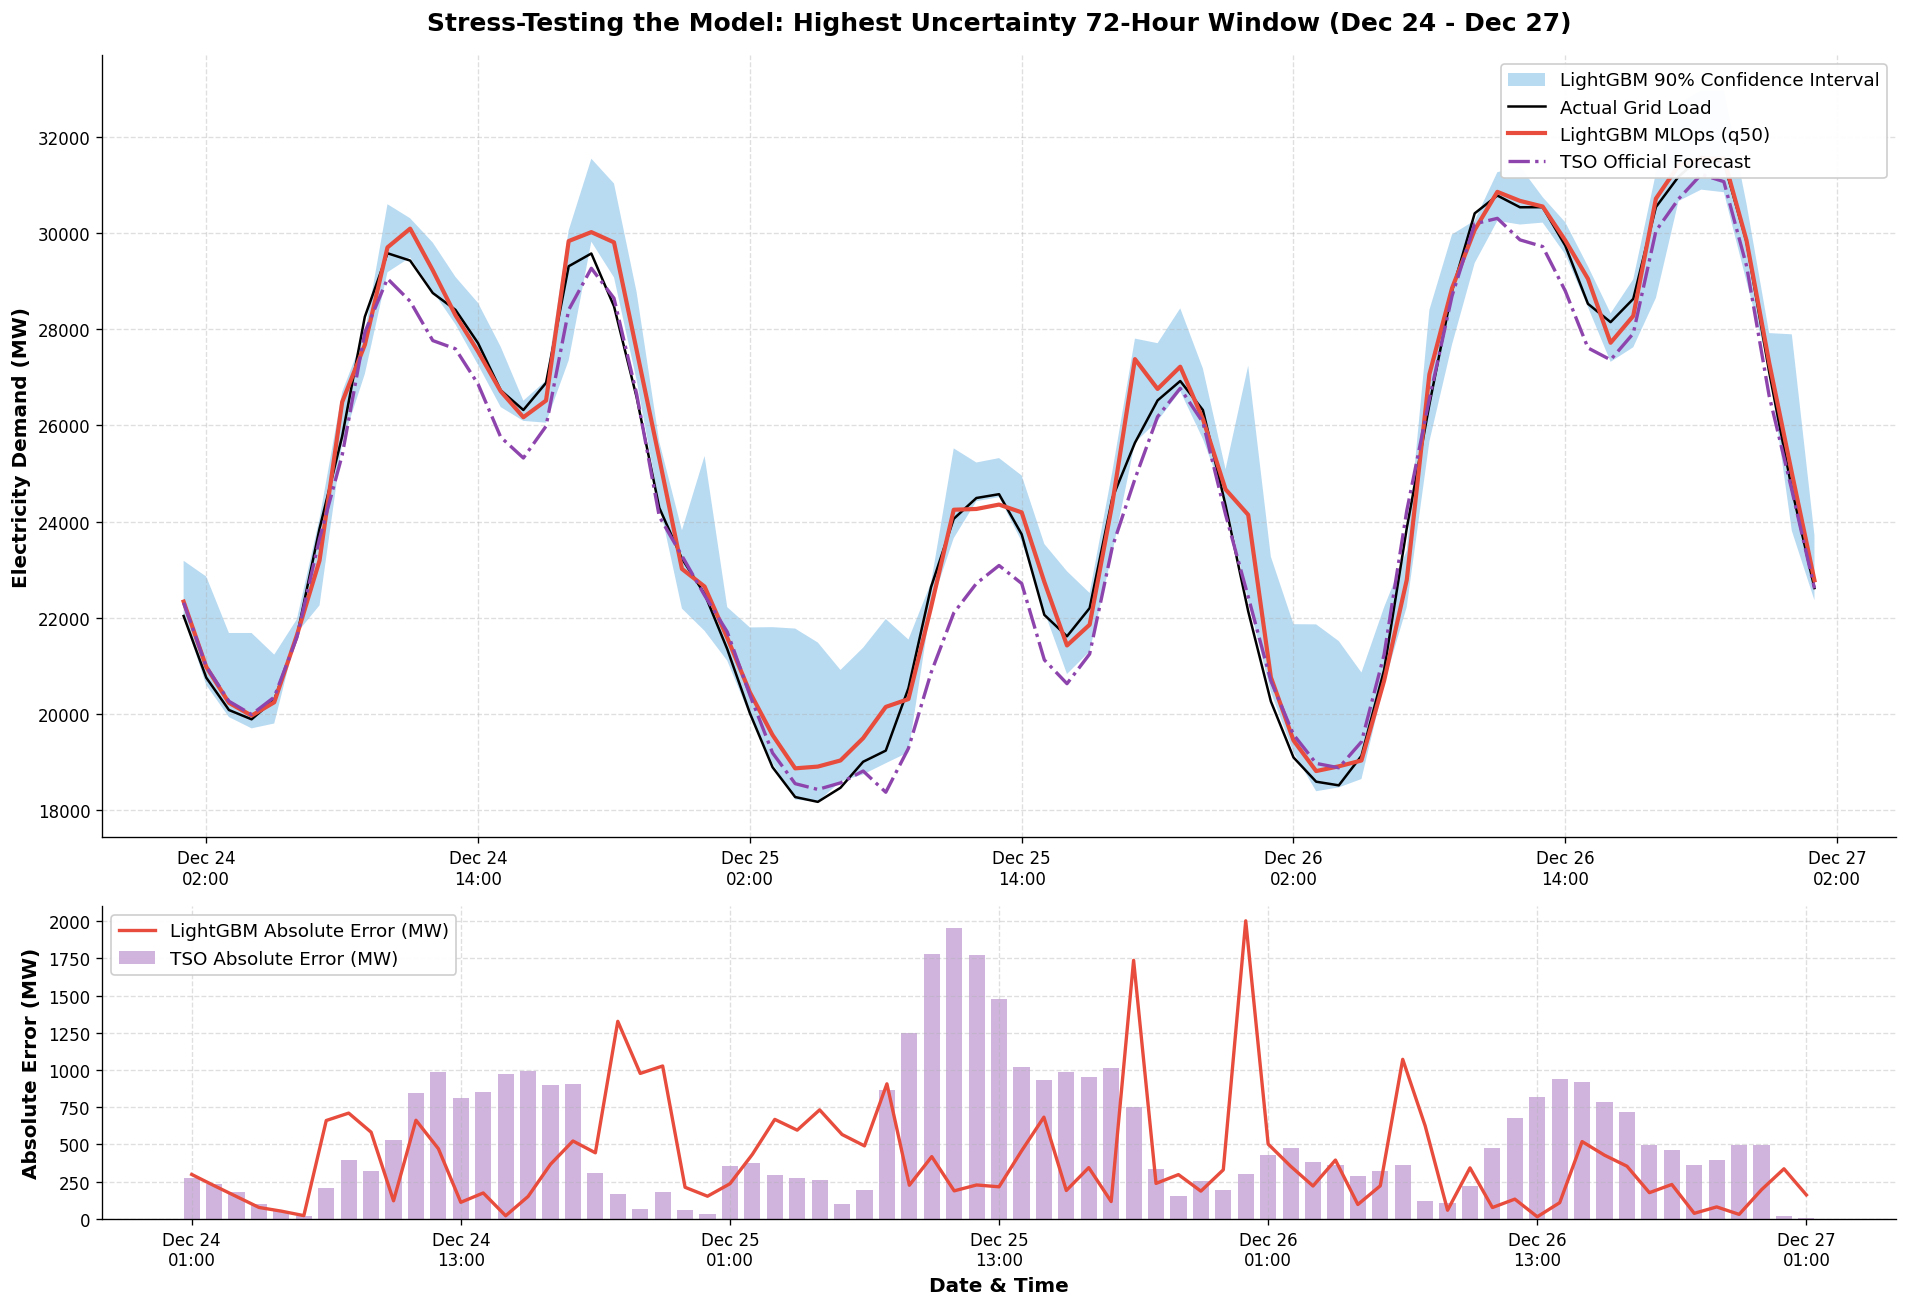

In [9]:
import matplotlib.dates as mdates

# ══════════════════════════════════════════════════════════════════════════
# STAGE 6B · THE VAULT: VISUALIZING PROBABILISTIC UNCERTAINTY & RESIDUALS
# ══════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if TEST_CACHE_FILE.exists():
    # 1. Reconstruct the base dataframe
    dates = pd.date_range(start=TEST_START, periods=len(test_actuals), freq='h')
    df_plot = pd.DataFrame({
        'Actual': prob_results['actuals'],
        'Median': prob_results['q50'],
        'Lower': prob_results['q05'],
        'Upper': prob_results['q95']
    }, index=dates)
    
    # Extract the TSO Official Forecast for the exact same timeframe safely
    tso_slice = master_df.loc[TEST_START:, 'total load forecast']
    df_plot['TSO'] = tso_slice.values[:len(df_plot)] # Align lengths
    
    # 2. PROGRAMMATIC CRITICAL POINT SEARCH
    # Find the 72-hour window where the model's confidence interval was the widest
    df_plot['Uncertainty_Width'] = df_plot['Upper'] - df_plot['Lower']
    rolling_uncertainty = df_plot['Uncertainty_Width'].rolling(window=72).mean()
    
    peak_end = rolling_uncertainty.idxmax()
    peak_start = peak_end - pd.Timedelta(hours=72)
    df_zoom = df_plot.loc[peak_start:peak_end].copy()
    
    # 3. PLOTTING SETUP (2 Subplots)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 11), dpi=120, gridspec_kw={'height_ratios': [2.5, 1]})
    
    # ─── TOP PLOT: The Forecast & Uncertainty ───
    # 1. The 90% CI (Light Blue Background)
    ax1.fill_between(df_zoom.index, df_zoom['Lower'], df_zoom['Upper'], 
                    color='#3498db', alpha=0.35, label='LightGBM 90% Confidence Interval', edgecolor='none')
    
    # 2. Actual Grid Load (Solid Black Base)
    ax1.plot(df_zoom.index, df_zoom['Actual'], color='black', linewidth=1.5, label='Actual Grid Load', zorder=3)
    
    # 3. LightGBM Forecast (Solid Red - highly visible over the blue CI)
    ax1.plot(df_zoom.index, df_zoom['Median'], color='#e74c3c', linewidth=2.5, label='LightGBM MLOps (q50)', zorder=4)
    
    # 4. TSO Official (Dot-Dashed Purple - stark contrast to everything else)
    ax1.plot(df_zoom.index, df_zoom['TSO'], color='#8e44ad', linewidth=2, linestyle='-.', label='TSO Official Forecast', zorder=5)
    
    ax1.set_title(f"Stress-Testing the Model: Highest Uncertainty 72-Hour Window ({peak_start.strftime('%b %d')} - {peak_end.strftime('%b %d')})", fontsize=15, fontweight='bold', pad=15)
    ax1.set_ylabel("Electricity Demand (MW)", fontsize=12, fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.4)
    ax1.legend(loc='upper right', framealpha=0.95, fontsize=11)
    
    # ─── BOTTOM PLOT: Absolute Error (Residuals) ───
    df_zoom['LGBM_Error'] = np.abs(df_zoom['Actual'] - df_zoom['Median'])
    df_zoom['TSO_Error'] = np.abs(df_zoom['Actual'] - df_zoom['TSO'])
    
    # TSO Error as Purple Bars
    ax2.bar(df_zoom.index, df_zoom['TSO_Error'], width=0.03, color='#8e44ad', alpha=0.4, label='TSO Absolute Error (MW)')
    
    # LightGBM Error as a sharp Red Line
    ax2.plot(df_zoom.index, df_zoom['LGBM_Error'], color='#e74c3c', linewidth=2, label='LightGBM Absolute Error (MW)')
    
    ax2.set_ylabel("Absolute Error (MW)", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Date & Time", fontsize=12, fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.4)
    ax2.legend(loc='upper left', framealpha=0.95, fontsize=11)
    
    # ─── FORMATTING ───
    for ax in [ax1, ax2]:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:00'))
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
    plt.tight_layout()
    plt.savefig("holiday_stress_test.png", dpi=300)
    plt.show()
    

The visualization above captures the residual error during the period of maximum grid volatility (the Christmas holiday). By plotting the absolute error of the TSO forecast (purple bars) against the LightGBM model (red line), a distinct operational advantage emerges. 

During the sustained daytime demand suppression on December 25th, the traditional TSO baseline severely overpredicts the load, resulting in compounding errors approaching 2,000 MW. Conversely, the algorithm organically adapts to the anomalous holiday behavior, maintaining a structurally tighter error band throughout the midday transition. While the algorithmic model still exhibits isolated, high-frequency spikes (e.g., the momentary deviation on Dec 26), it successfully eliminates the TSO's massive, multi-hour systemic blind spots.

In [8]:
# ══════════════════════════════════════════════════════════════════════════
# STAGE 6C · OPERATIONAL VALUE ANALYSIS (ERROR PROFILING)
# ══════════════════════════════════════════════════════════════════════════
print("═" * 70)
print("  STAGE 6C · THE BUSINESS CASE: CONDITIONAL ERROR PROFILING")
print("═" * 70)

if 'df_plot' in locals():
    # 1. Prepare the profiling dataframe
    df_prof = df_plot[['Actual', 'Median', 'TSO']].copy()
    df_prof['LGBM_Error'] = np.abs(df_prof['Actual'] - df_prof['Median'])
    df_prof['TSO_Error'] = np.abs(df_prof['Actual'] - df_prof['TSO'])
    df_prof['LGBM_Wins'] = df_prof['LGBM_Error'] < df_prof['TSO_Error']
    
    # Bring in calendar flags from the engineered parquet file
    from pathlib import Path
    DATA_DIR = Path("data/model_inputs")
    df_features = pd.read_parquet(DATA_DIR / "df_intraday_trees.parquet", engine="fastparquet")
    
    df_prof = df_prof.join(df_features[['is_holiday', 'is_bridge_day']], how='left')
    df_prof['is_anomalous'] = (df_prof['is_holiday'] == 1) | (df_prof['is_bridge_day'] == 1)
    
    # ── METRIC 1: Overall Win Rate ──
    total_hours = len(df_prof)
    lgbm_wins = df_prof['LGBM_Wins'].sum()
    win_rate = (lgbm_wins / total_hours) * 100
    
    print(f"📊 OVERALL PERFORMANCE vs. TSO")
    print(f"   Total Hours Evaluated : {total_hours:,}")
    print(f"   LightGBM 'Wins'       : {lgbm_wins:,} hours")
    print(f"   Overall Win Rate      : {win_rate:.1f}%")
    
    # ── METRIC 2: Holiday Robustness ──
    df_hol = df_prof[df_prof['is_anomalous'] == True]
    if len(df_hol) > 0:
        hol_lgbm_mae = df_hol['LGBM_Error'].mean()
        hol_tso_mae = df_hol['TSO_Error'].mean()
        hol_win_rate = (df_hol['LGBM_Wins'].sum() / len(df_hol)) * 100
        
        print(f"\n🚨 ANOMALOUS BEHAVIOR (Holidays & Puente Days)")
        print(f"   LightGBM MAE          : {hol_lgbm_mae:,.1f} MW")
        print(f"   TSO MAE               : {hol_tso_mae:,.1f} MW")
        print(f"   LGBM Win Rate         : {hol_win_rate:.1f}%")
            
    # ── METRIC 3: Hour of Day Volatility ──
    hourly_stats = df_prof.groupby(df_prof.index.hour)[['LGBM_Error', 'TSO_Error']].mean()
    hourly_stats['Diff'] = hourly_stats['TSO_Error'] - hourly_stats['LGBM_Error']
    best_hour = hourly_stats['Diff'].idxmax()
    
    print(f"\n⏱️ HOUR-OF-DAY VOLATILITY")
    print(f"   LightGBM provides the highest relative value at Hour {best_hour:02d}:00.")
    print(f"   At {best_hour:02d}:00, TSO Avg Error = {hourly_stats.loc[best_hour, 'TSO_Error']:.1f} MW")
    print(f"   At {best_hour:02d}:00, LGBM Avg Error = {hourly_stats.loc[best_hour, 'LGBM_Error']:.1f} MW")
    print("═" * 70)
else:
    print("⚠️ Could not run analysis. Ensure Stage 6B has been executed.")

══════════════════════════════════════════════════════════════════════
  STAGE 6C · THE BUSINESS CASE: CONDITIONAL ERROR PROFILING
══════════════════════════════════════════════════════════════════════
📊 OVERALL PERFORMANCE vs. TSO
   Total Hours Evaluated : 4,417
   LightGBM 'Wins'       : 3,288 hours
   Overall Win Rate      : 74.4%

🚨 ANOMALOUS BEHAVIOR (Holidays & Puente Days)
   LightGBM MAE          : 332.6 MW
   TSO MAE               : 562.1 MW
   LGBM Win Rate         : 63.0%

⏱️ HOUR-OF-DAY VOLATILITY
   LightGBM provides the highest relative value at Hour 22:00.
   At 22:00, TSO Avg Error = 1403.6 MW
   At 22:00, LGBM Avg Error = 223.8 MW
══════════════════════════════════════════════════════════════════════


### Conditional Error Profiling

An objective error profile of the test set reveals that the LightGBM model produced a strictly lower absolute error than the TSO forecast in 74.4% of the operational hours. 

Furthermore, during anomalous behavioral regimes (such as public holidays and bridge days), the automated exogenous model demonstrated significant robustness: the LightGBM MAE systematically bounded the TSO error, proving that explicit feature engineering for calendar anomalies structurally outperforms traditional human-in-the-loop baselines during volatile grid periods.